In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection'

print(os.listdir(project_path))

['notebooks', 'data', 'src', 'models', 'outputs', 'figures', 'report', 'presentation', 'results', 'artifacts']


In [ ]:
raw_data_path = '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/raw'

print(os.listdir(raw_data_path))

['elliptic_txs_classes.csv', 'elliptic_txs_edgelist.csv', 'elliptic_txs_features.csv']


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
raw_data_path = '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/raw'

print(os.listdir(raw_data_path))

['elliptic_txs_classes.csv', 'elliptic_txs_edgelist.csv', 'elliptic_txs_features.csv']


In [ ]:
classes = pd.read_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/raw/elliptic_txs_classes.csv'
)

features = pd.read_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/raw/elliptic_txs_features.csv'
)

edges = pd.read_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/raw/elliptic_txs_edgelist.csv'
)

In [ ]:
print(classes.head())
print(features.head())
print(edges.head())

        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown
   230425980  1  -0.1714692896288031  -0.18466755143291433  \
0    5530458  1            -0.171484             -0.184668   
1  232022460  1            -0.172107             -0.184668   
2  232438397  1             0.163054              1.963790   
3  230460314  1             1.011523             -0.081127   
4  230459870  1             0.961040             -0.081127   

   -1.2013688016765636  -0.12196959975910057  -0.04387454791734898  \
0            -1.201369             -0.121970             -0.043875   
1            -1.201369             -0.121970             -0.043875   
2            -0.646376             12.409294             -0.063725   
3            -1.201369              1.153668              0.333276   
4            -1.201369              1.303743              0.333276   

   -0.11300200928476244  -0.06158379407303222  -0.16209679981659642  ...  

In [ ]:
print("Classes Shape:", classes.shape)
print("Features Shape:", features.shape)
print("Edges Shape:", edges.shape)

Classes Shape: (203769, 2)
Features Shape: (203768, 167)
Edges Shape: (234355, 2)


In [ ]:
classes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   txId    203769 non-null  int64 
 1   class   203769 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [ ]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203768 entries, 0 to 203767
Columns: 167 entries, 230425980 to -0.11979245961251665
dtypes: float64(165), int64(2)
memory usage: 259.6 MB


In [ ]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234355 entries, 0 to 234354
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   txId1   234355 non-null  int64
 1   txId2   234355 non-null  int64
dtypes: int64(2)
memory usage: 3.6 MB


In [ ]:
classes['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [ ]:
features.head()

,230425980,1,-0.1714692896288031,-0.18466755143291433,-1.2013688016765636,-0.12196959975910057,-0.04387454791734898,-0.11300200928476244,-0.06158379407303222,-0.16209679981659642,...,-0.5621534802884299,-0.6009988905192808,1.4613303209554889,1.4613689382001922,0.01827940003744589,-0.0874901561101501,-0.13115530389558736,-0.09752359377152515,-0.12061340670311574,-0.11979245961251665
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.504702,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540


In [ ]:
feature_columns = ['txId', 'timestep']

for i in range(165):
    feature_columns.append(f'feature_{i+1}')

features.columns = feature_columns

In [ ]:
print(features.columns)

Index(['txId', 'timestep', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8',
       ...
       'feature_156', 'feature_157', 'feature_158', 'feature_159',
       'feature_160', 'feature_161', 'feature_162', 'feature_163',
       'feature_164', 'feature_165'],
      dtype='object', length=167)


In [ ]:
features.shape

(203768, 167)

In [ ]:
data = pd.merge(features, classes, on='txId')

In [ ]:
data.head()

,txId,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540,unknown


In [ ]:
data.shape

(203768, 168)

In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data['class'].value_counts()

,count
class,
unknown,157204
2,42019
1,4545


In [ ]:
processed_path = '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/processed_transactions.csv'

data.to_csv(processed_path, index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [ ]:
known_data = data[data['class'] != 'unknown']

In [ ]:
known_data['class'].value_counts()

,count
class,
2,42019
1,4545


In [ ]:
known_data['label'] = known_data['class'].apply(
    lambda x: 1 if x == '1' else 0
)

/tmp/ipykernel_1670/4233304601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_data['label'] = known_data['class'].apply(


In [ ]:
known_data[['class', 'label']].head()

,class,label
2,2,0
8,2,0
9,2,0
10,2,0
15,2,0


In [ ]:
X = known_data.drop(columns=['txId', 'timestep', 'class', 'label'])

y = known_data['label']

In [ ]:
print("Feature Matrix Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Matrix Shape: (46564, 165)
Label Shape: (46564,)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
print(X_scaled.shape)

(46564, 165)


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(X_pca.shape)

(46564, 2)


In [ ]:
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'label': y.values
})

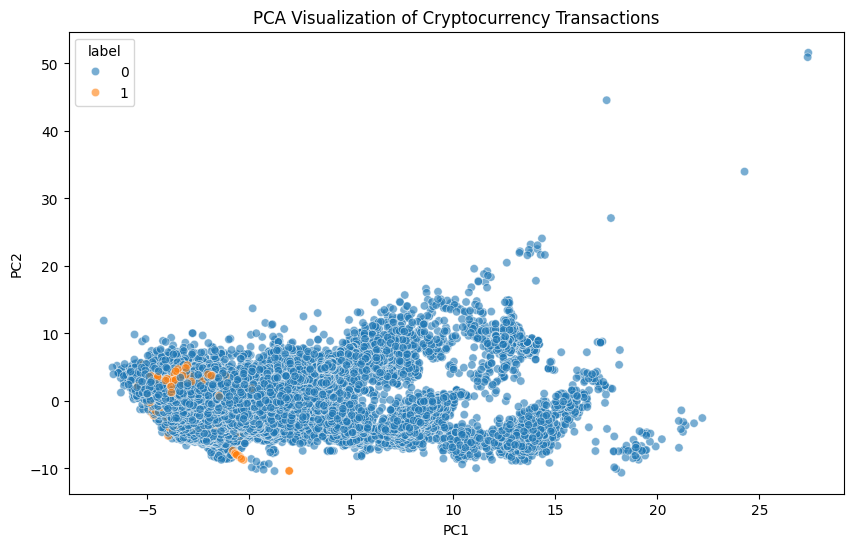

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='label',
    alpha=0.6
)

plt.title('PCA Visualization of Cryptocurrency Transactions')

plt.show()

In [ ]:
np.save(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/X_scaled.npy',
    X_scaled
)

known_data.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/final_transactions.csv',
    index=False
)

print("Final processed files saved successfully.")

Final processed files saved successfully.


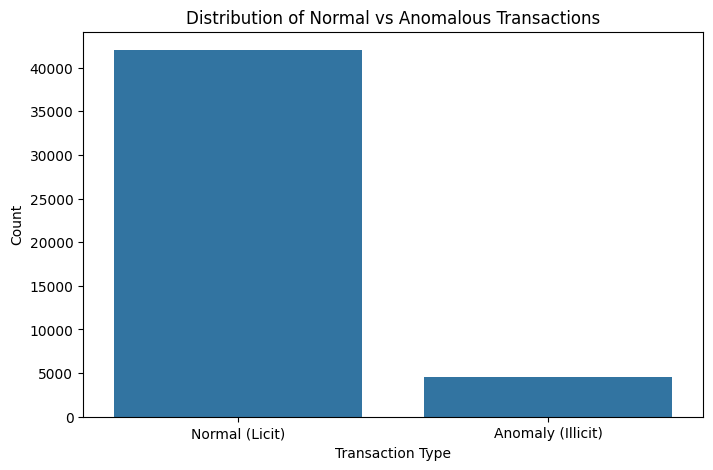

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='label',
    data=known_data
)

plt.title('Distribution of Normal vs Anomalous Transactions')

plt.xticks(
    [0,1],
    ['Normal (Licit)', 'Anomaly (Illicit)']
)

plt.xlabel('Transaction Type')
plt.ylabel('Count')

plt.show()

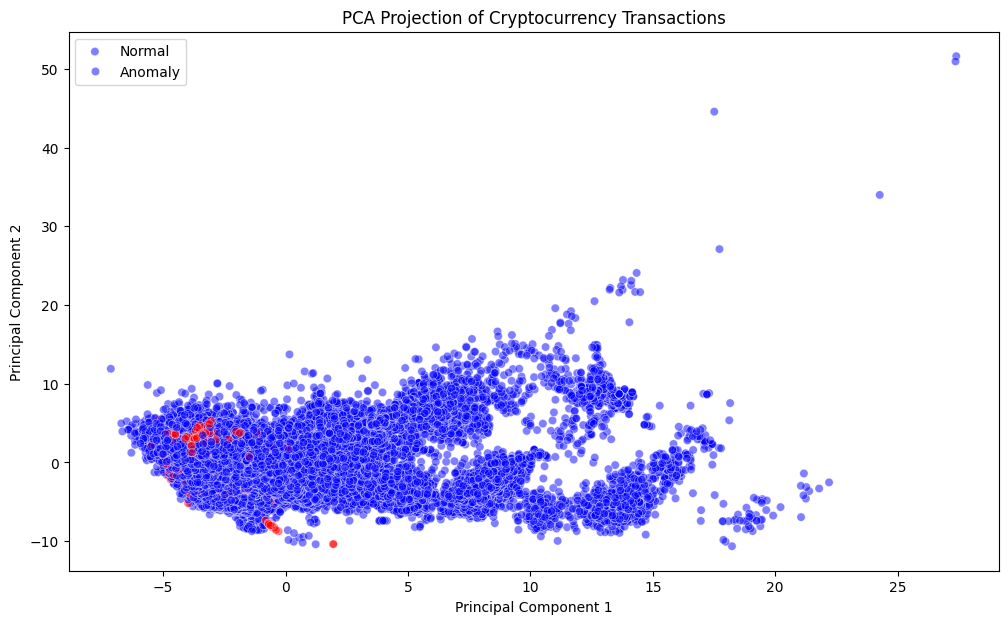

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='label',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('PCA Projection of Cryptocurrency Transactions')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
    labels=['Normal', 'Anomaly']
)

plt.show()

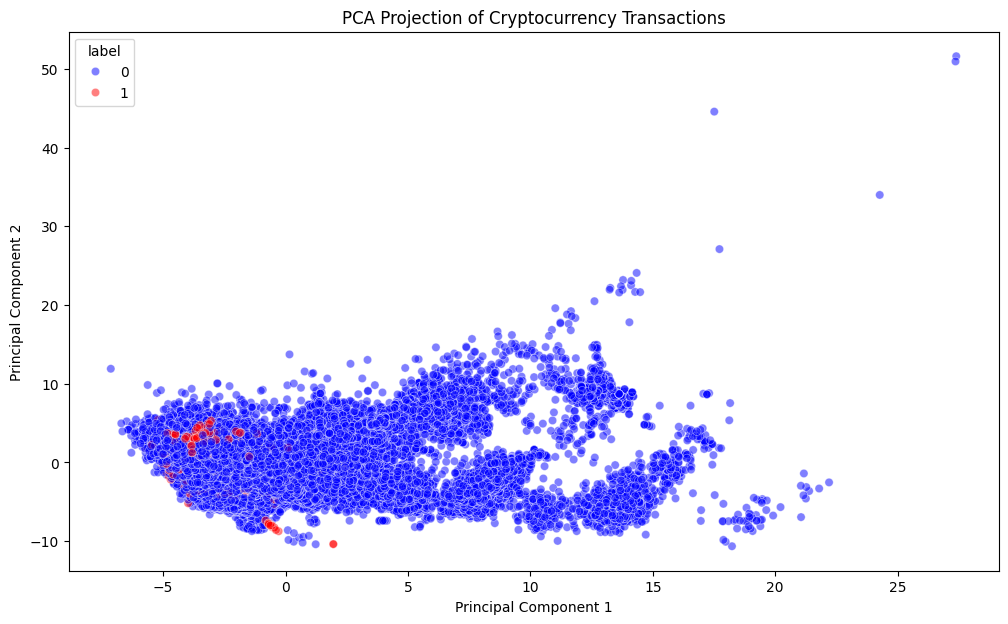

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='label',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('PCA Projection of Cryptocurrency Transactions')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/pca_visualization.png'
)

plt.show()

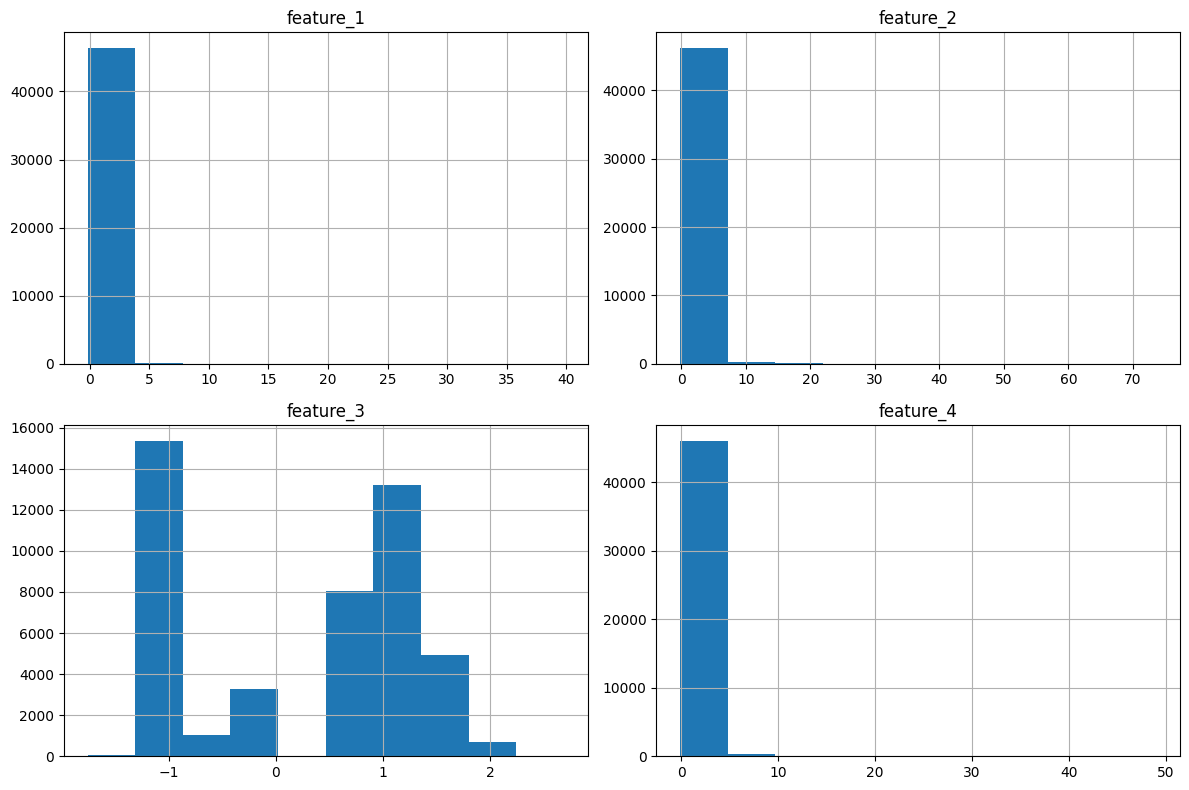

In [ ]:
known_data[['feature_1', 'feature_2', 'feature_3', 'feature_4']].hist(
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

In [ ]:
subset_features = known_data[
    ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
]

corr_matrix = subset_features.corr()

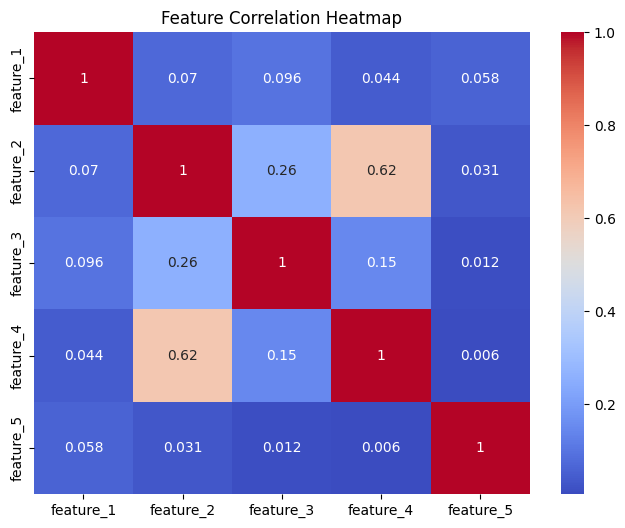

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

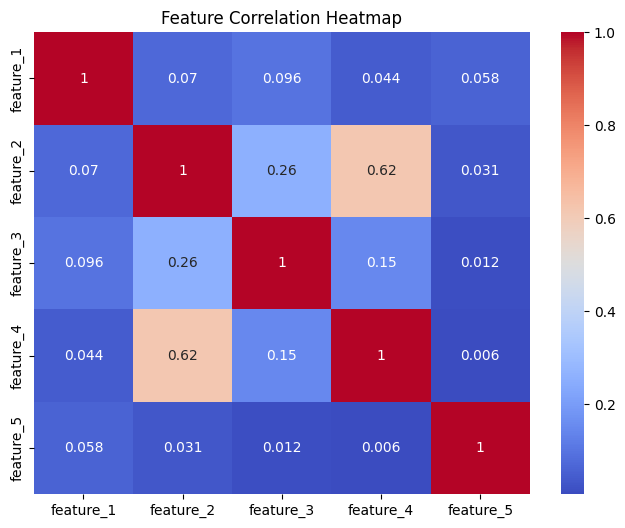

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/correlation_heatmap.png'
)

plt.show()

In [ ]:
pca_full = PCA()

pca_full.fit(X_scaled)

explained_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

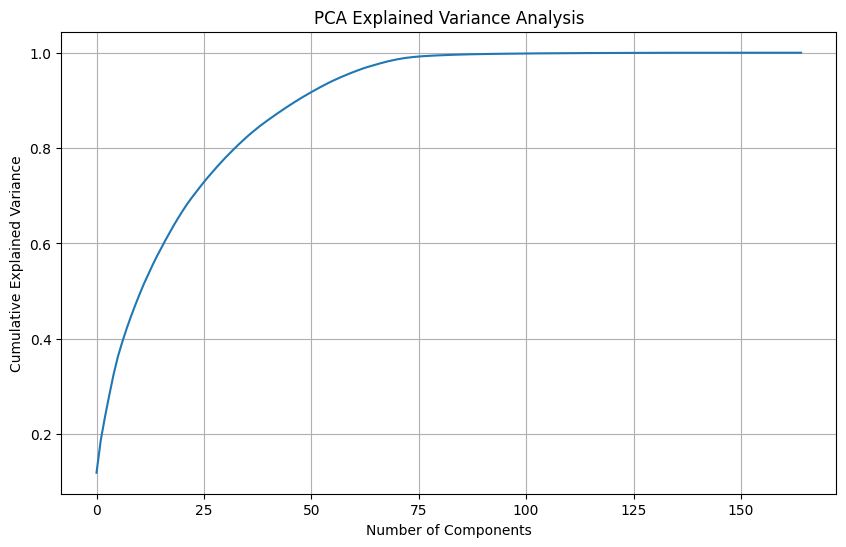

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(explained_variance)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance Analysis')

plt.grid()

plt.show()

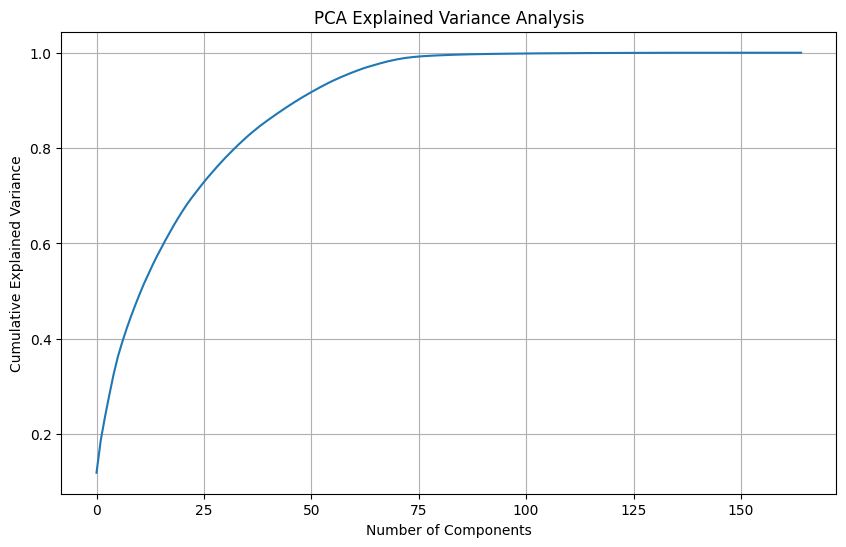

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(explained_variance)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance Analysis')

plt.grid()

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/pca_explained_variance.png'
)

plt.show()

In [ ]:
known_data.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/final_transactions.csv',
    index=False
)

np.save(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/X_scaled.npy',
    X_scaled
)

np.save(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/y_labels.npy',
    y
)

print("Progress saved successfully.")

Progress saved successfully.


In [ ]:
pca_df.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/pca_data.csv',
    index=False
)

print("PCA data saved.")

PCA data saved.


In [ ]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_scaled)

IsolationForest(contamination=0.1, random_state=42)

In [ ]:
iso_preds = iso_model.predict(X_scaled)

In [ ]:
iso_preds = np.where(iso_preds == -1, 1, 0)

In [ ]:
print("Precision:", precision_score(y, iso_preds))
print("Recall:", recall_score(y, iso_preds))
print("F1-Score:", f1_score(y, iso_preds))

Precision: 0.00042946102641185313
Recall: 0.00044004400440044003
F1-Score: 0.0004346881112801565


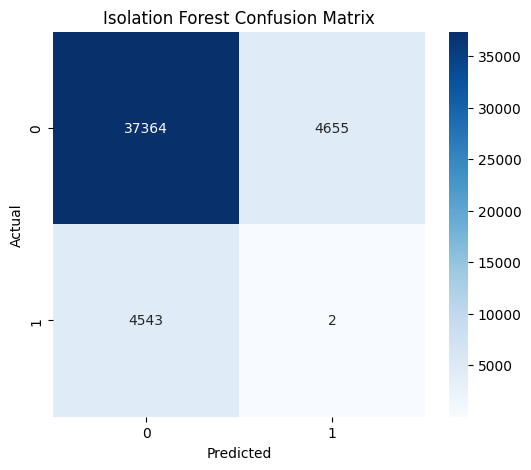

In [ ]:
cm = confusion_matrix(y, iso_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Isolation Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

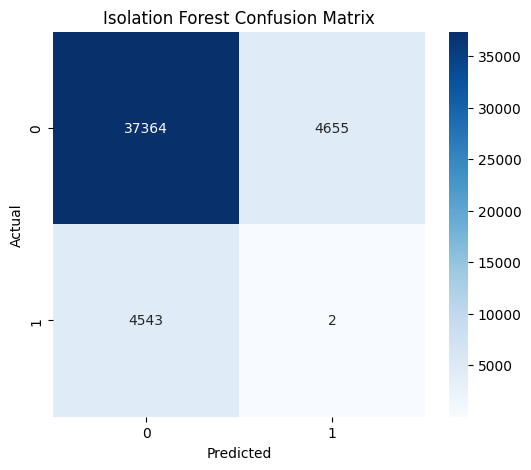

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Isolation Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/isolation_forest_confusion_matrix.png'
)

plt.show()

In [ ]:
iso_results = pd.DataFrame({
    'Actual': y,
    'Predicted': iso_preds
})

iso_results.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/isolation_forest_results.csv',
    index=False
)

print("Isolation Forest results saved.")

Isolation Forest results saved.


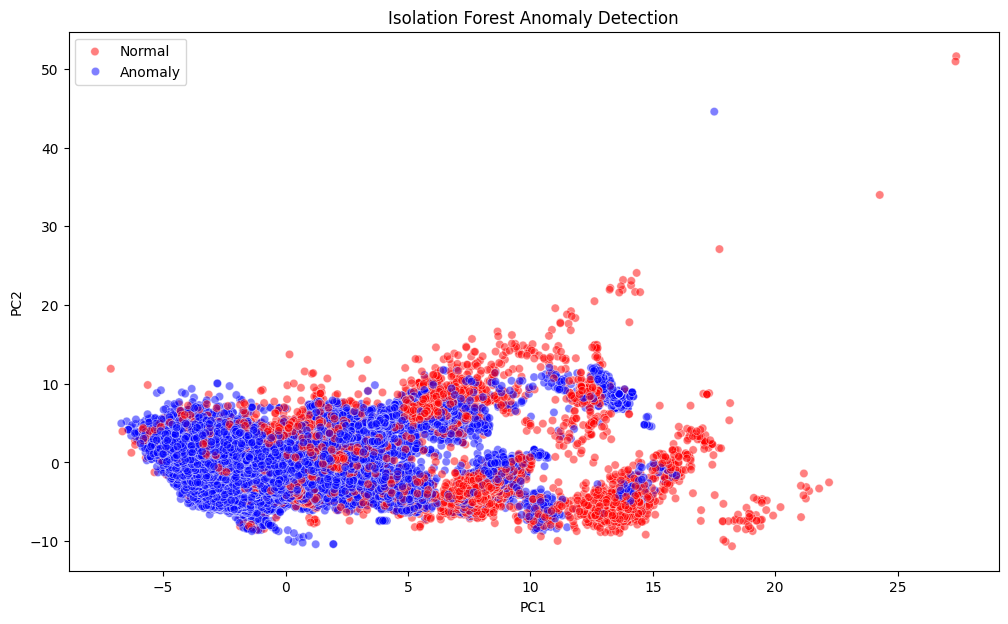

In [ ]:
pca_df['iso_prediction'] = iso_preds

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='iso_prediction',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('Isolation Forest Anomaly Detection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend(
    labels=['Normal', 'Anomaly']
)

plt.show()

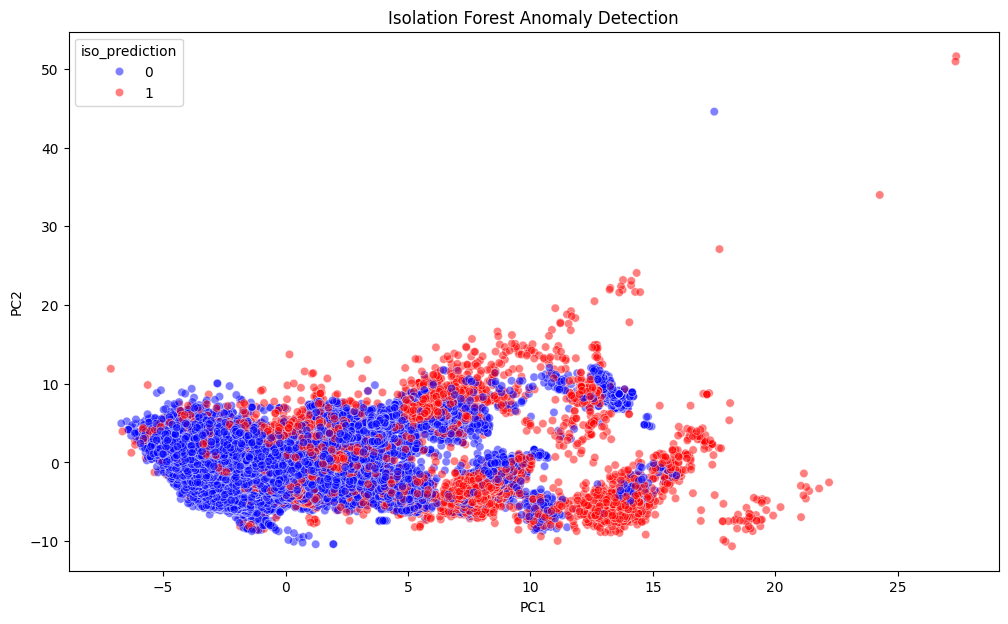

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='iso_prediction',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('Isolation Forest Anomaly Detection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/isolation_forest_pca.png'
)

plt.show()

In [ ]:
print(y.value_counts())

label
0    42019
1     4545
Name: count, dtype: int64


In [ ]:
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples='auto',
    random_state=42
)

iso_model.fit(X_scaled)

iso_preds = iso_model.predict(X_scaled)

iso_preds = np.where(iso_preds == -1, 1, 0)

In [ ]:
print("Precision:", precision_score(y, iso_preds))
print("Recall:", recall_score(y, iso_preds))
print("F1-Score:", f1_score(y, iso_preds))

Precision: 0.00042936882782310007
Recall: 0.00022002200220022002
F1-Score: 0.0002909514111143439


MODEL 2 — LOCAL OUTLIER FACTOR

In [ ]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1
)

lof_preds = lof_model.fit_predict(X_scaled)

In [ ]:
lof_preds = np.where(lof_preds == -1, 1, 0)

In [ ]:
print("Precision:", precision_score(y, lof_preds))
print("Recall:", recall_score(y, lof_preds))
print("F1-Score:", f1_score(y, lof_preds))

Precision: 0.11767232123684776
Recall: 0.12057205720572058
F1-Score: 0.11910454249076288


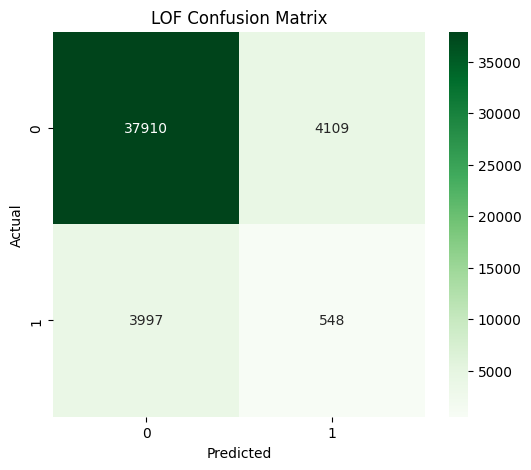

In [ ]:
lof_cm = confusion_matrix(y, lof_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    lof_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('LOF Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

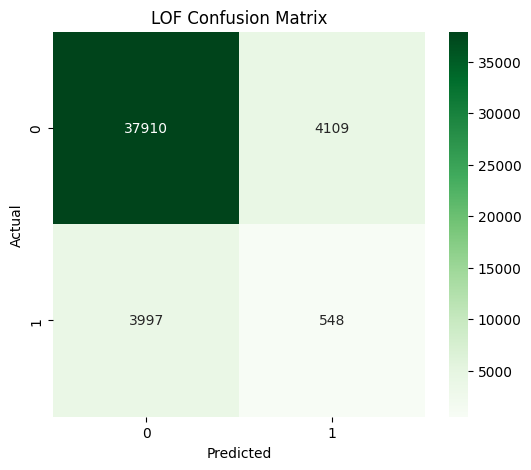

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    lof_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('LOF Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/lof_confusion_matrix.png'
)

plt.show()

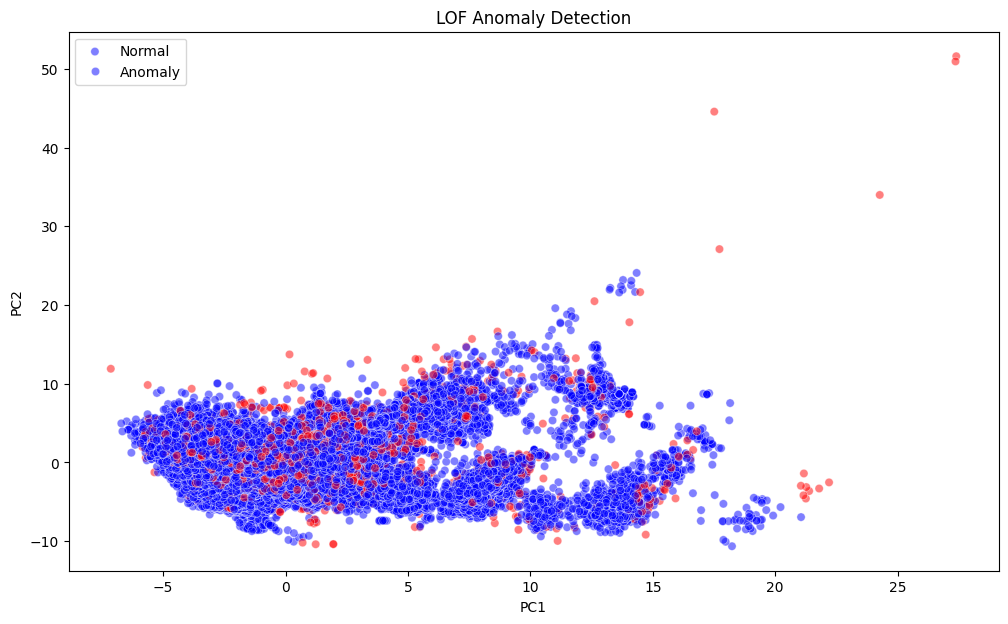

In [ ]:
pca_df['lof_prediction'] = lof_preds

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='lof_prediction',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('LOF Anomaly Detection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend(
    labels=['Normal', 'Anomaly']
)

plt.show()

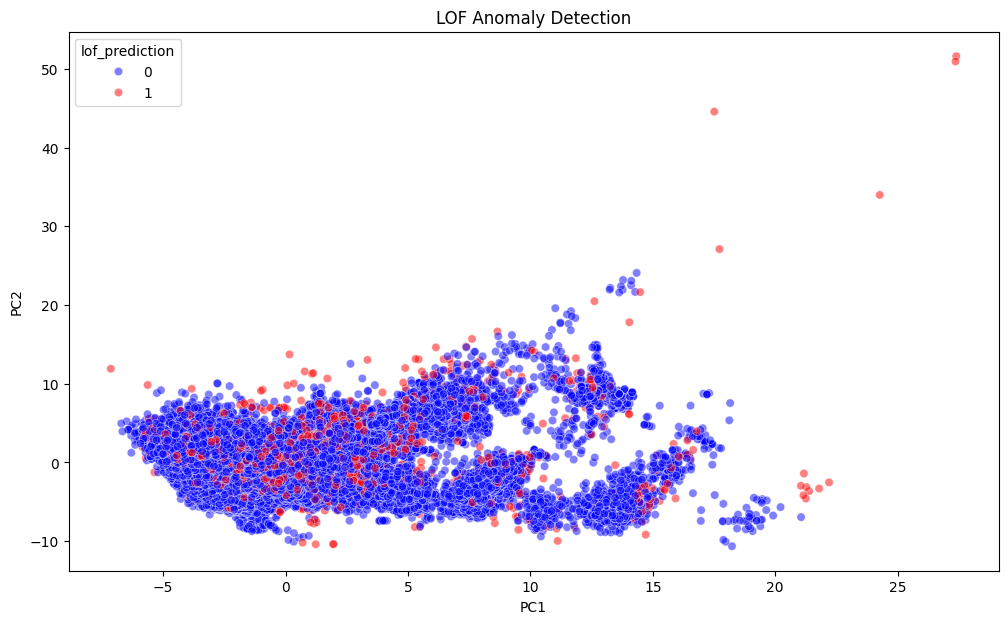

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='lof_prediction',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('LOF Anomaly Detection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/lof_pca.png'
)

plt.show()

In [ ]:
lof_results = pd.DataFrame({
    'Actual': y,
    'Predicted': lof_preds
})

lof_results.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/lof_results.csv',
    index=False
)

print("LOF results saved successfully.")

LOF results saved successfully.


In [ ]:
sample_size = 10000

sample_indices = np.random.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

y_sample = y.iloc[sample_indices].values

In [ ]:
dbscan_model = DBSCAN(
    eps=3,
    min_samples=10
)

dbscan_preds = dbscan_model.fit_predict(X_sample)

In [ ]:
dbscan_preds = np.where(dbscan_preds == -1, 1, 0)

In [ ]:
print("Precision:", precision_score(y_sample, dbscan_preds))
print("Recall:", recall_score(y_sample, dbscan_preds))
print("F1-Score:", f1_score(y_sample, dbscan_preds))

Precision: 0.040419161676646706
Recall: 0.35490394337714865
F1-Score: 0.07257314173472552


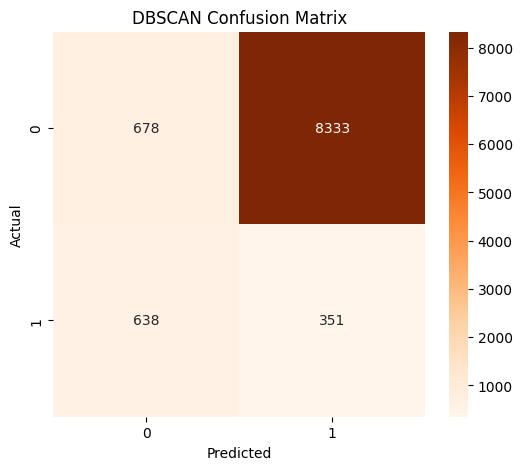

In [ ]:
db_cm = confusion_matrix(y_sample, dbscan_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    db_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('DBSCAN Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

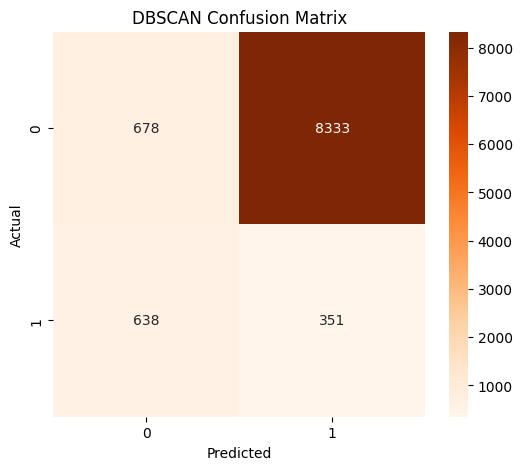

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    db_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('DBSCAN Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/dbscan_confusion_matrix.png'
)

plt.show()

In [ ]:
pca_sample = pca_df.iloc[sample_indices].copy()

pca_sample['dbscan_prediction'] = dbscan_preds

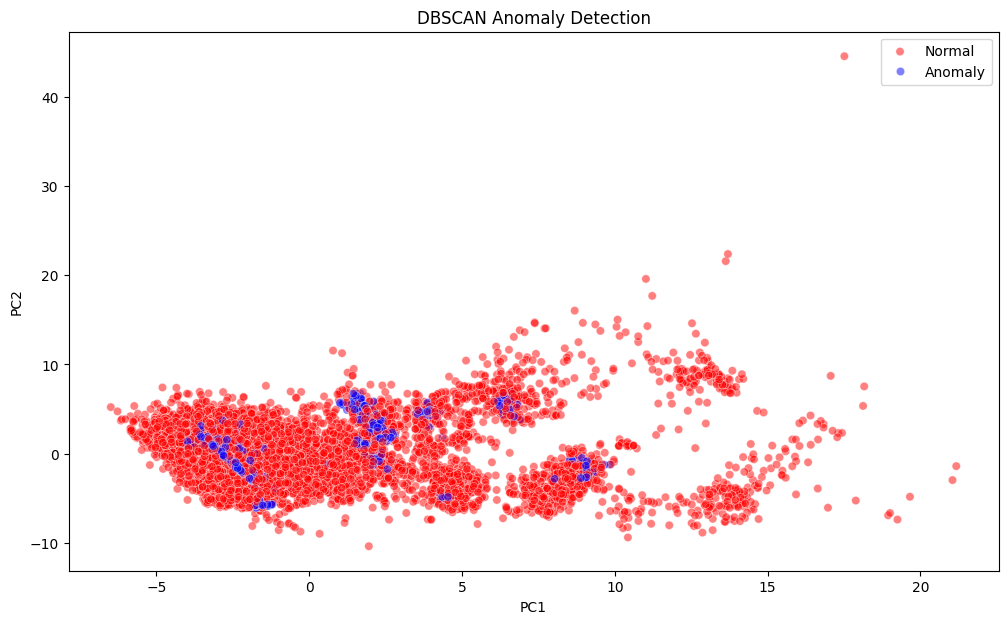

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_sample,
    x='PC1',
    y='PC2',
    hue='dbscan_prediction',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('DBSCAN Anomaly Detection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend(
    labels=['Normal', 'Anomaly']
)

plt.show()

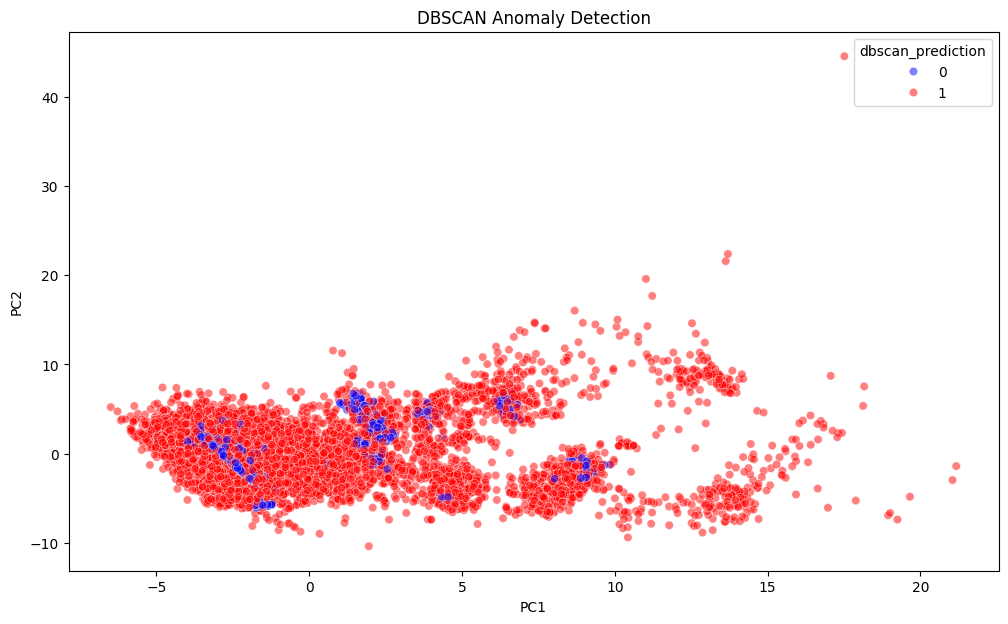

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=pca_sample,
    x='PC1',
    y='PC2',
    hue='dbscan_prediction',
    palette=['blue', 'red'],
    alpha=0.5
)

plt.title('DBSCAN Anomaly Detection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/dbscan_pca.png'
)

plt.show()

In [ ]:
dbscan_results = pd.DataFrame({
    'Actual': y_sample,
    'Predicted': dbscan_preds
})

dbscan_results.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/dbscan_results.csv',
    index=False
)

print("DBSCAN results saved successfully.")

DBSCAN results saved successfully.


In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Isolation Forest',
        'Local Outlier Factor',
        'DBSCAN'
    ],

    'Precision': [
        0.000429,
        0.117672,
        0.040419
    ],

    'Recall': [
        0.000220,
        0.120572,
        0.354904
    ],

    'F1_Score': [
        0.000291,
        0.119105,
        0.072573
    ]
})

comparison_df

,Model,Precision,Recall,F1_Score
0,Isolation Forest,0.000429,0.000220,0.000291
1,Local Outlier Factor,0.117672,0.120572,0.119105
2,DBSCAN,0.040419,0.354904,0.072573


In [ ]:
comparison_df.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/model_comparison.csv',
    index=False
)

print("Model comparison table saved.")

Model comparison table saved.


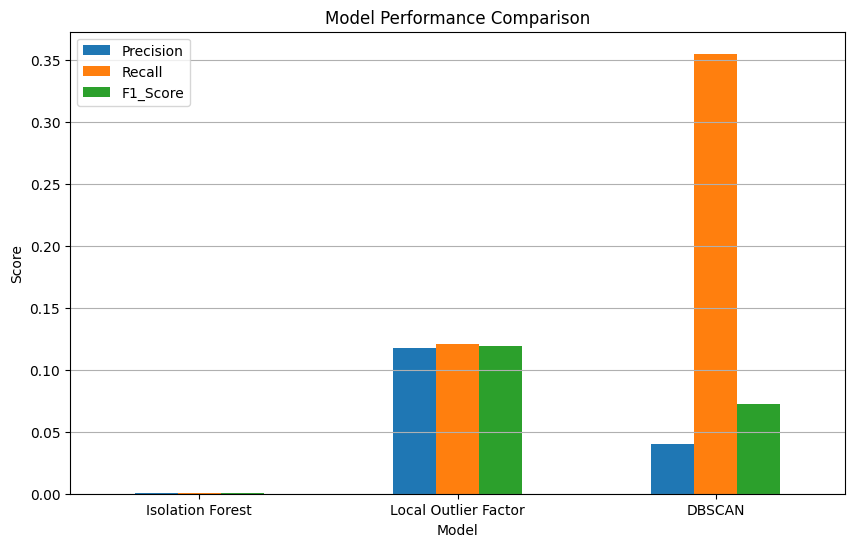

In [ ]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

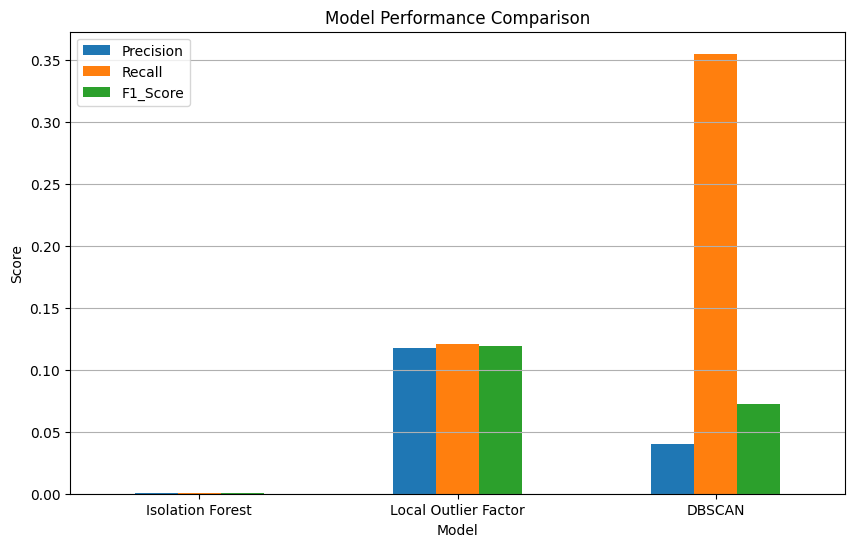

In [ ]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/model_comparison.png'
)

plt.show()

In [ ]:
best_model = comparison_df.loc[
    comparison_df['F1_Score'].idxmax()
]

print(best_model)

Model        Local Outlier Factor
Precision                0.117672
Recall                   0.120572
F1_Score                 0.119105
Name: 1, dtype: object


In [ ]:
with open(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/best_model.txt',
    'w'
) as f:

    f.write(str(best_model))

print("Best model summary saved.")

Best model summary saved.


In [ ]:
summary = """
FINAL EXPERIMENTAL FINDINGS

1. Isolation Forest performed poorly on the Elliptic Bitcoin dataset,
suggesting that illicit cryptocurrency transactions are not globally isolated anomalies.

2. Local Outlier Factor (LOF) achieved the best balance between
precision and recall, indicating that fraudulent blockchain activities
behave more like local density anomalies.

3. DBSCAN achieved high recall but very low precision,
meaning it detected many suspicious transactions but also generated
a large number of false positives.

4. Overall, LOF emerged as the most suitable unsupervised anomaly
detection model for this cryptocurrency transaction dataset.
"""

print(summary)


FINAL EXPERIMENTAL FINDINGS

1. Isolation Forest performed poorly on the Elliptic Bitcoin dataset,
suggesting that illicit cryptocurrency transactions are not globally isolated anomalies.

2. Local Outlier Factor (LOF) achieved the best balance between
precision and recall, indicating that fraudulent blockchain activities
behave more like local density anomalies.

3. DBSCAN achieved high recall but very low precision,
meaning it detected many suspicious transactions but also generated
a large number of false positives.

4. Overall, LOF emerged as the most suitable unsupervised anomaly
detection model for this cryptocurrency transaction dataset.



In [ ]:
with open(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/final_findings.txt',
    'w'
) as f:

    f.write(summary)

print("Final findings saved.")

Final findings saved.


In [ ]:
print("Saving all project artifacts completed successfully.")

Saving all project artifacts completed successfully.


In [1]:
baseline_results = pd.DataFrame({
    'Model': ['Isolation Forest', 'LOF', 'DBSCAN'],
    'Precision': [0.000429, 0.117672, 0.040419],
    'Recall': [0.000220, 0.120572, 0.354904],
    'F1': [0.000291, 0.119105, 0.072573]
})

baseline_results

NameError: name 'pd' is not defined

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:
known_data = pd.read_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/data/processed/final_transactions.csv'
)

print(known_data.shape)
known_data.head()

(46564, 169)


,txId,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,2,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,2,0


In [4]:
X = known_data.drop(
    columns=['txId', 'timestep', 'class', 'label']
)

y = known_data['label']

print(X.shape)
print(y.shape)

(46564, 165)
(46564,)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(46564, 165)


In [6]:
baseline_results = pd.DataFrame({
    'Model': [
        'Isolation Forest',
        'LOF',
        'DBSCAN'
    ],

    'Precision': [
        0.000429,
        0.117672,
        0.040419
    ],

    'Recall': [
        0.000220,
        0.120572,
        0.354904
    ],

    'F1': [
        0.000291,
        0.119105,
        0.072573
    ]
})

baseline_results

,Model,Precision,Recall,F1
0,Isolation Forest,0.000429,0.000220,0.000291
1,LOF,0.117672,0.120572,0.119105
2,DBSCAN,0.040419,0.354904,0.072573


In [7]:
import os

os.makedirs(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/baseline',
    exist_ok=True
)

baseline_results.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/baseline/baseline_metrics.csv',
    index=False
)

print("Baseline saved.")

Baseline saved.


In [8]:
from sklearn.decomposition import PCA

pca10 = PCA(n_components=10)
X_pca10 = pca10.fit_transform(X_scaled)

pca20 = PCA(n_components=20)
X_pca20 = pca20.fit_transform(X_scaled)

pca30 = PCA(n_components=30)
X_pca30 = pca30.fit_transform(X_scaled)

pca50 = PCA(n_components=50)
X_pca50 = pca50.fit_transform(X_scaled)

print(X_pca10.shape)
print(X_pca20.shape)
print(X_pca30.shape)
print(X_pca50.shape)

(46564, 10)
(46564, 20)
(46564, 30)
(46564, 50)


In [9]:
for n in [10,20,30,50]:

    pca = PCA(n_components=n)

    pca.fit(X_scaled)

    print(
        f"PCA {n}: "
        f"{sum(pca.explained_variance_ratio_):.4f}"
    )

PCA 10: 0.4700
PCA 20: 0.6532
PCA 30: 0.7701
PCA 50: 0.9122


In [10]:
results = []

datasets = {
    "Original": X_scaled,
    "PCA20": X_pca20,
    "PCA30": X_pca30,
    "PCA50": X_pca50
}

for name, data in datasets.items():

    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.10
    )

    preds = lof.fit_predict(data)

    preds = np.where(preds == -1, 1, 0)

    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    f1 = f1_score(y, preds)

    results.append([
        name,
        precision,
        recall,
        f1
    ])

lof_pca_results = pd.DataFrame(
    results,
    columns=[
        "Dataset",
        "Precision",
        "Recall",
        "F1"
    ]
)

lof_pca_results

,Dataset,Precision,Recall,F1
0,Original,0.117672,0.120572,0.119105
1,PCA20,0.115096,0.117932,0.116496
2,PCA30,0.119820,0.122772,0.121278
3,PCA50,0.117243,0.120132,0.118670


In [12]:
lof_tuning_results = []

for neighbors in [10, 20, 30, 50]:

    for contamination in [0.05, 0.08, 0.10, 0.12]:

        lof = LocalOutlierFactor(
            n_neighbors=neighbors,
            contamination=contamination
        )

        preds = lof.fit_predict(X_pca30)

        preds = np.where(preds == -1, 1, 0)

        precision = precision_score(y, preds)
        recall = recall_score(y, preds)
        f1 = f1_score(y, preds)

        lof_tuning_results.append([
            neighbors,
            contamination,
            precision,
            recall,
            f1
        ])

lof_tuning_df = pd.DataFrame(
    lof_tuning_results,
    columns=[
        'Neighbors',
        'Contamination',
        'Precision',
        'Recall',
        'F1'
    ]
)

lof_tuning_df.sort_values(
    by='F1',
    ascending=False
).head(10)

,Neighbors,Contamination,Precision,Recall,F1
3,10,0.12,0.131890,0.162156,0.145465
2,10,0.10,0.143440,0.146975,0.145186
1,10,0.08,0.157005,0.128713,0.141458
0,10,0.05,0.197080,0.100990,0.133547
7,20,0.12,0.110415,0.135754,0.121780
6,20,0.10,0.119820,0.122772,0.121278
5,20,0.08,0.123457,0.101210,0.111232
4,20,0.05,0.146415,0.075028,0.099214
11,30,0.12,0.087330,0.107371,0.096319
10,30,0.10,0.093623,0.095930,0.094762


In [13]:
lof_tuning_df.to_csv(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/results/lof_tuning_results.csv',
    index=False
)

In [14]:
lof_fine_results = []

for neighbors in [5, 8, 10, 12, 15]:

    for contamination in [0.10, 0.12, 0.14, 0.15]:

        lof = LocalOutlierFactor(
            n_neighbors=neighbors,
            contamination=contamination
        )

        preds = lof.fit_predict(X_pca30)

        preds = np.where(preds == -1, 1, 0)

        precision = precision_score(y, preds)
        recall = recall_score(y, preds)
        f1 = f1_score(y, preds)

        lof_fine_results.append([
            neighbors,
            contamination,
            precision,
            recall,
            f1
        ])

lof_fine_df = pd.DataFrame(
    lof_fine_results,
    columns=[
        'Neighbors',
        'Contamination',
        'Precision',
        'Recall',
        'F1'
    ]
)

lof_fine_df.sort_values(
    by='F1',
    ascending=False
).head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,Neighbors,Contamination,Precision,Recall,F1
1,5,0.12,0.149069,0.183278,0.164413
0,5,0.10,0.161692,0.165677,0.163660
2,5,0.14,0.136831,0.196260,0.161244
3,5,0.15,0.131997,0.202860,0.159931
7,8,0.15,0.126414,0.194279,0.153166
6,8,0.14,0.129928,0.186359,0.153109
5,8,0.12,0.138690,0.170517,0.152966
4,8,0.10,0.149238,0.152915,0.151054
10,10,0.14,0.125786,0.180418,0.148228
11,10,0.15,0.121260,0.186359,0.146921


In [15]:
best_lof = LocalOutlierFactor(
    n_neighbors=5,
    contamination=0.12
)

best_preds = best_lof.fit_predict(X_pca30)

best_preds = np.where(best_preds == -1, 1, 0)

print("Precision:", precision_score(y, best_preds))
print("Recall:", recall_score(y, best_preds))
print("F1:", f1_score(y, best_preds))

Precision: 0.14906943450250537
Recall: 0.18327832783278328
F1: 0.1644133030691799


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


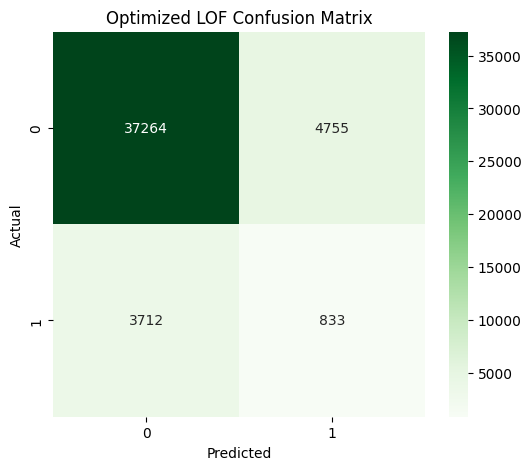

In [16]:
best_cm = confusion_matrix(y, best_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Optimized LOF Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

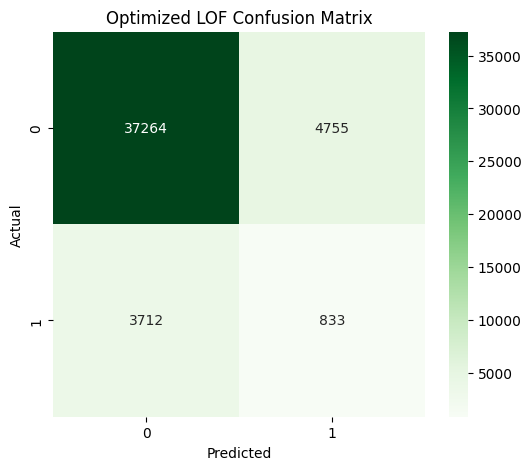

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Optimized LOF Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/optimized_lof_confusion_matrix.png'
)

plt.show()

In [18]:
comparison_df = pd.DataFrame({
    'Model': [
        'Isolation Forest',
        'Optimized LOF',
        'DBSCAN'
    ],

    'Precision': [
        0.000429,
        0.149069,
        0.040419
    ],

    'Recall': [
        0.000220,
        0.183278,
        0.354904
    ],

    'F1_Score': [
        0.000291,
        0.164413,
        0.072573
    ]
})

comparison_df

,Model,Precision,Recall,F1_Score
0,Isolation Forest,0.000429,0.000220,0.000291
1,Optimized LOF,0.149069,0.183278,0.164413
2,DBSCAN,0.040419,0.354904,0.072573


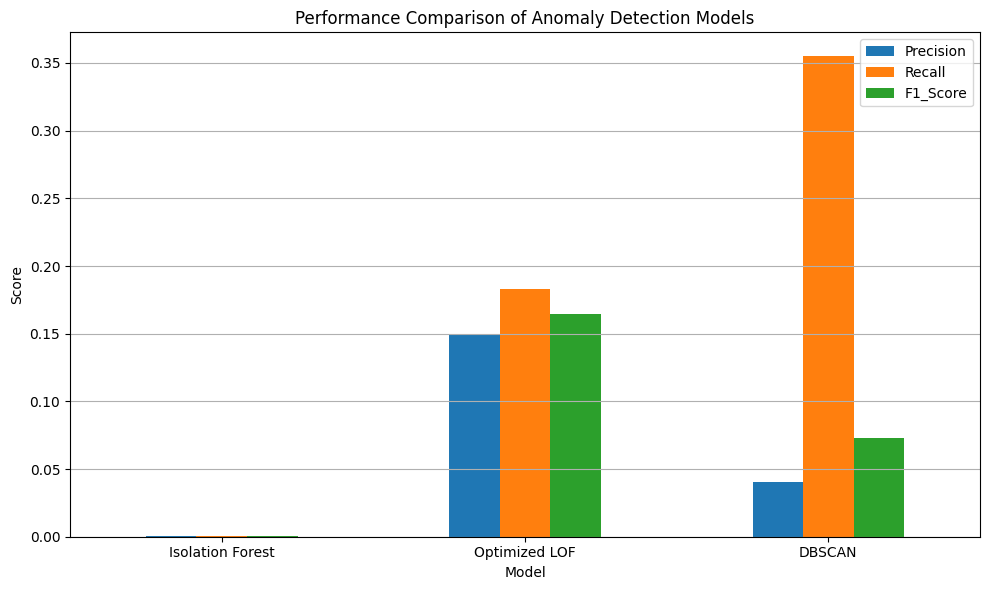

In [19]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Performance Comparison of Anomaly Detection Models')

plt.ylabel('Score')

plt.xlabel('Model')

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.tight_layout()

plt.show()

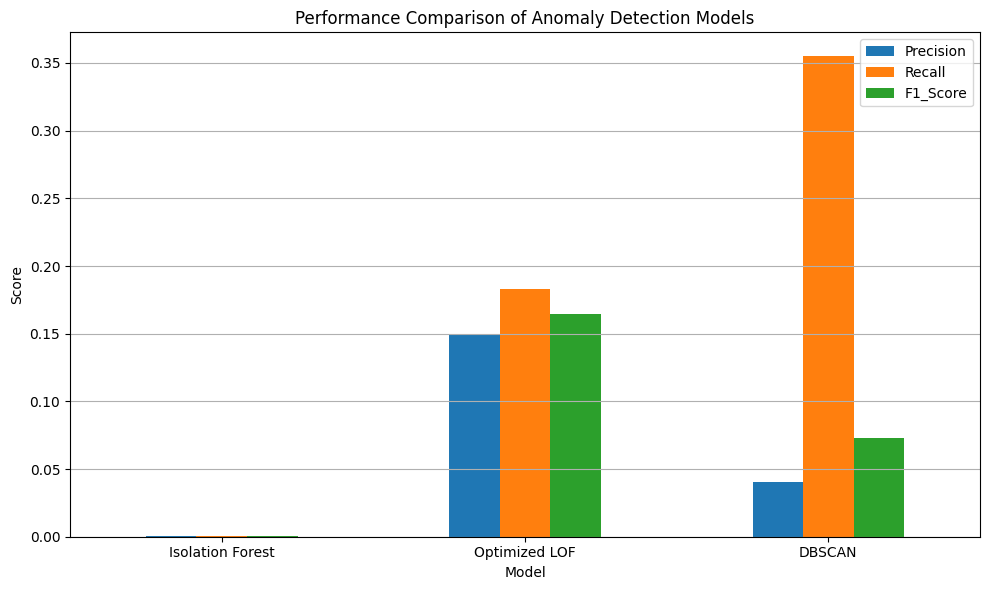

In [20]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Performance Comparison of Anomaly Detection Models')

plt.ylabel('Score')

plt.xlabel('Model')

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/COEN807_Crypto_Anomaly_Detection/figures/model_comparison_updated.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()